In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = pd.read_csv("../data/visitor_prediction_features_snapshot.csv")
data["month"] = pd.to_datetime(data["month"])

print(data.shape)
data.head()

(9104, 10)


,country,month,visitor_arrivals,gdp,exchange_rate,public_holiday_count,aircraft_passengers,traffic_volume,hotel_rate,hotel_occupancy
0,Australia,1978-01-01,20379.0,135608.0,NaN,2,NaN,NaN,NaN,NaN
1,Australia,1978-02-01,18852.0,135608.0,NaN,0,NaN,NaN,NaN,NaN
2,Australia,1978-03-01,20819.0,135608.0,NaN,9,NaN,NaN,NaN,NaN
3,Australia,1978-04-01,18697.0,135608.0,NaN,1,NaN,NaN,NaN,NaN
4,Australia,1978-05-01,19797.0,135608.0,NaN,3,NaN,NaN,NaN,NaN


In [28]:
total_data = pd.read_csv("../data/total_visitor_arrivals_monthly.csv")
total_data["month"] = pd.to_datetime(total_data["month"])
print(total_data.shape)
total_data.head()

(569, 2)


,month,total_visitor_arrivals
0,1978-01-01,165678.0
1,1978-02-01,163401.0
2,1978-03-01,166743.0
3,1978-04-01,167155.0
4,1978-05-01,169163.0


In [29]:
data.columns.tolist()

['country',
 'month',
 'visitor_arrivals',
 'gdp',
 'exchange_rate',
 'public_holiday_count',
 'aircraft_passengers',
 'traffic_volume',
 'hotel_rate',
 'hotel_occupancy']

In [30]:
missing = pd.DataFrame({
    "null_count": data.isna().sum(),
    "null_pct": (data.isna().sum() / len(data) * 100).round(2)
}).sort_values("null_pct", ascending=False)

missing

,null_count,null_pct
hotel_rate,5760,63.27
hotel_occupancy,5760,63.27
exchange_rate,5508,60.50
traffic_volume,5264,57.82
aircraft_passengers,384,4.22
gdp,34,0.37
country,0,0.00
month,0,0.00
visitor_arrivals,0,0.00
public_holiday_count,0,0.00


In [31]:
filtered_data = data[data["month"] >= "2008-01-01"].copy()

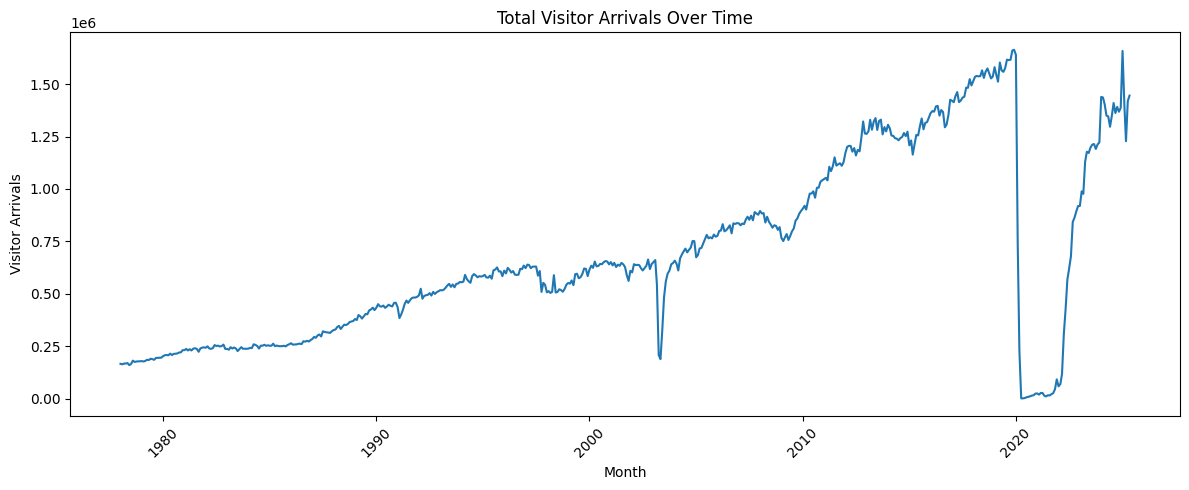

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(total_data["month"], total_data["total_visitor_arrivals"])
plt.title("Total Visitor Arrivals Over Time")
plt.xlabel("Month")
plt.ylabel("Visitor Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
top_countries = (
    data.groupby("country", as_index=False)["visitor_arrivals"]
    .sum()
    .sort_values("visitor_arrivals", ascending=False)
    .head(15)
)

top_countries

,country,visitor_arrivals
7,Japan,30608390.0
0,Australia,27761661.0
5,India,23832097.0
14,United Kingdom,16417517.0
15,United States,16256879.0
4,Hong Kong,12529613.0
13,Taiwan,11692273.0
3,Germany,8191891.0
2,France,4380707.0
9,New Zealand,4193346.0


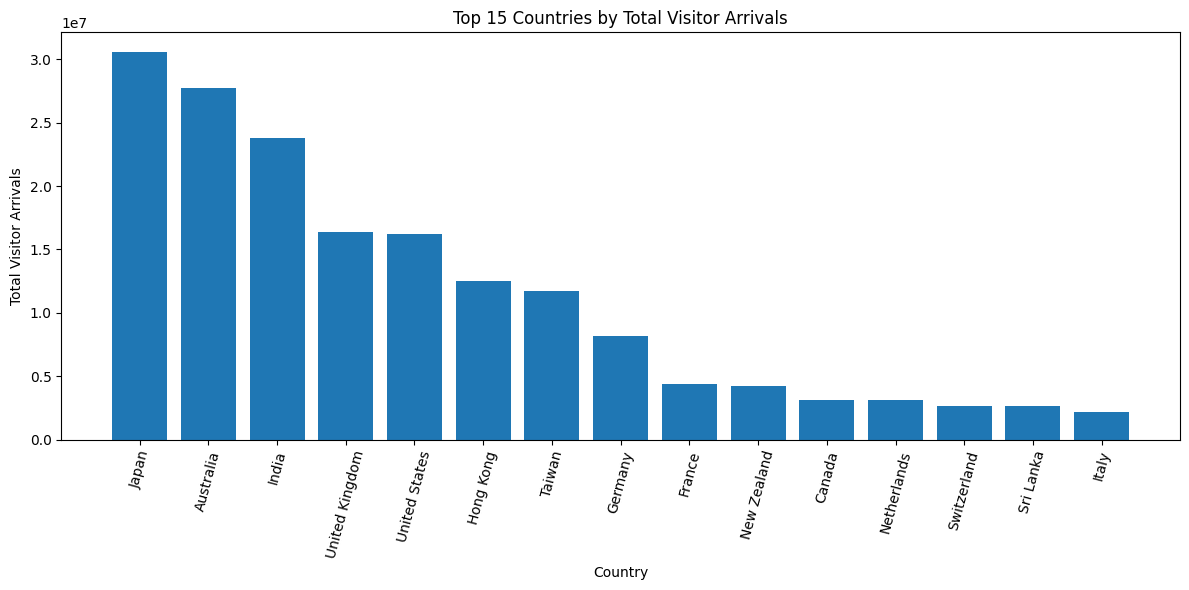

In [34]:
plt.figure(figsize=(12, 6))
plt.bar(top_countries["country"], top_countries["visitor_arrivals"])
plt.title("Top 15 Countries by Total Visitor Arrivals")
plt.xlabel("Country")
plt.ylabel("Total Visitor Arrivals")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

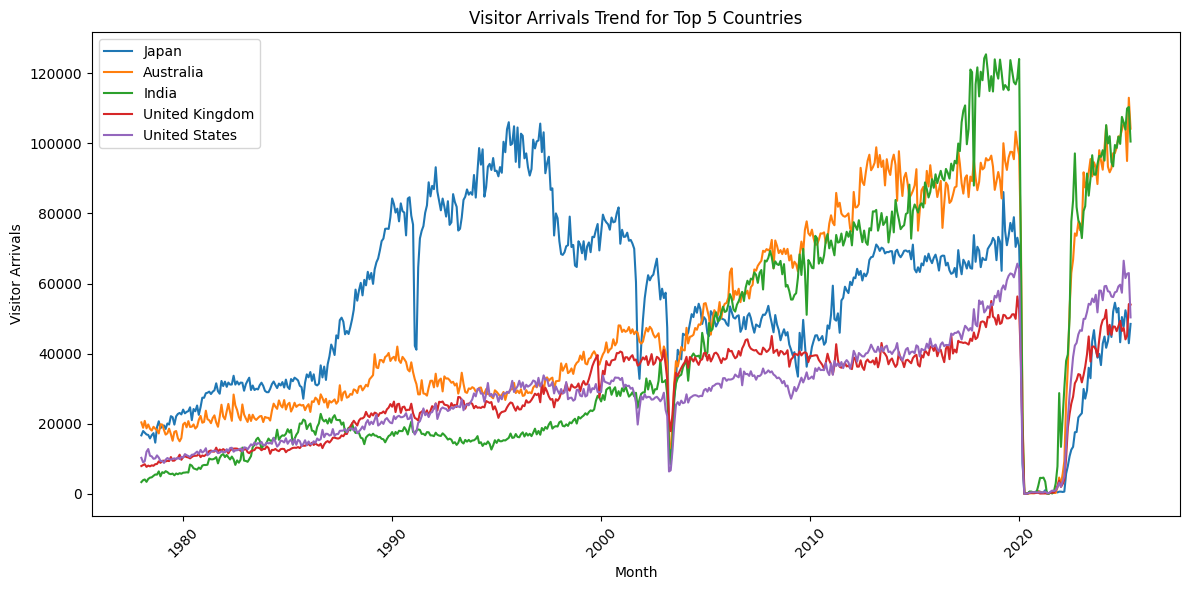

In [35]:
top5 = top_countries["country"].head(5).tolist()

plt.figure(figsize=(12, 6))
for country in top5:
    subset = data[data["country"] == country].sort_values("month")
    plt.plot(subset["month"], subset["visitor_arrivals"], label=country)

plt.title("Visitor Arrivals Trend for Top 5 Countries")
plt.xlabel("Month")
plt.ylabel("Visitor Arrivals")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

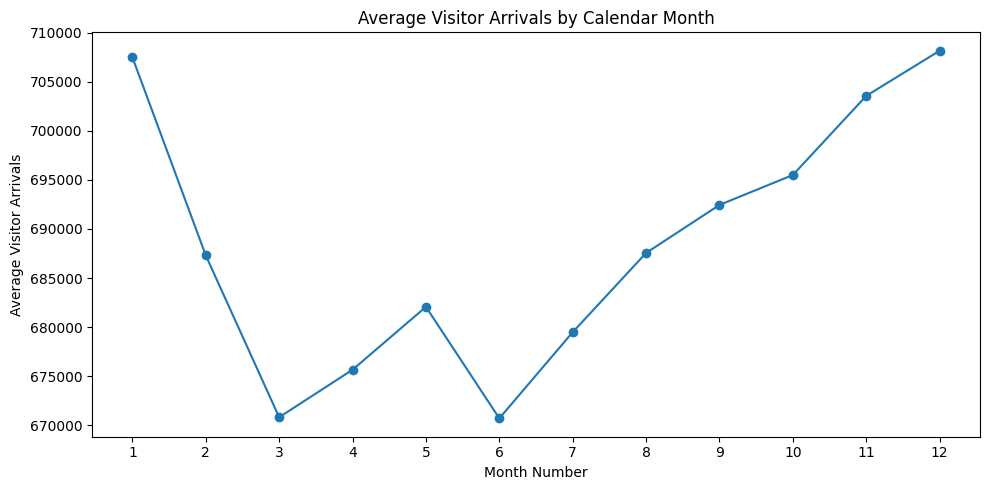

In [36]:
total_data["month_num"] = total_data["month"].dt.month

seasonality = (
    total_data.groupby("month_num", as_index=False)["total_visitor_arrivals"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(seasonality["month_num"], seasonality["total_visitor_arrivals"], marker="o")
plt.title("Average Visitor Arrivals by Calendar Month")
plt.xlabel("Month Number")
plt.ylabel("Average Visitor Arrivals")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [37]:
data["month_num"] = data["month"].dt.month

seasonality = (
    data.groupby("month_num", as_index=False)["visitor_arrivals"]
    .mean()
)

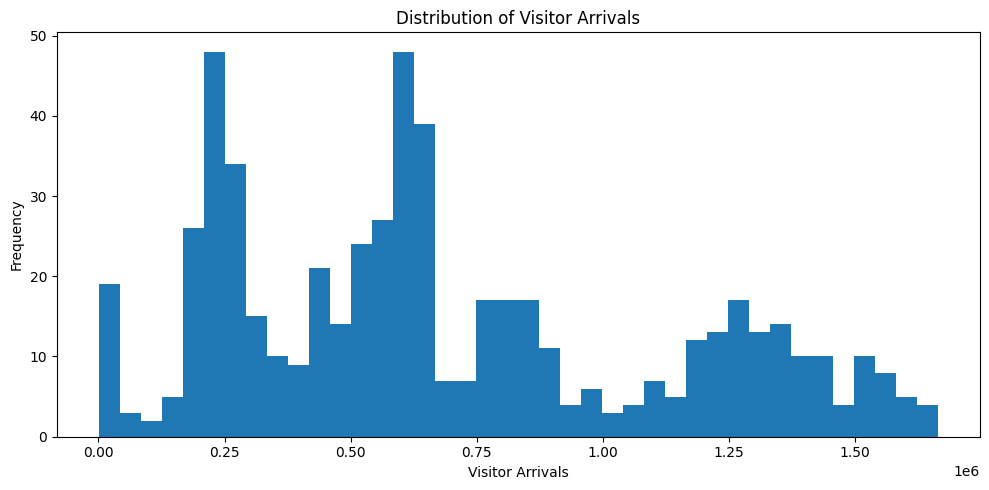

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(total_data["total_visitor_arrivals"].dropna(), bins=40)
plt.title("Distribution of Visitor Arrivals")
plt.xlabel("Visitor Arrivals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

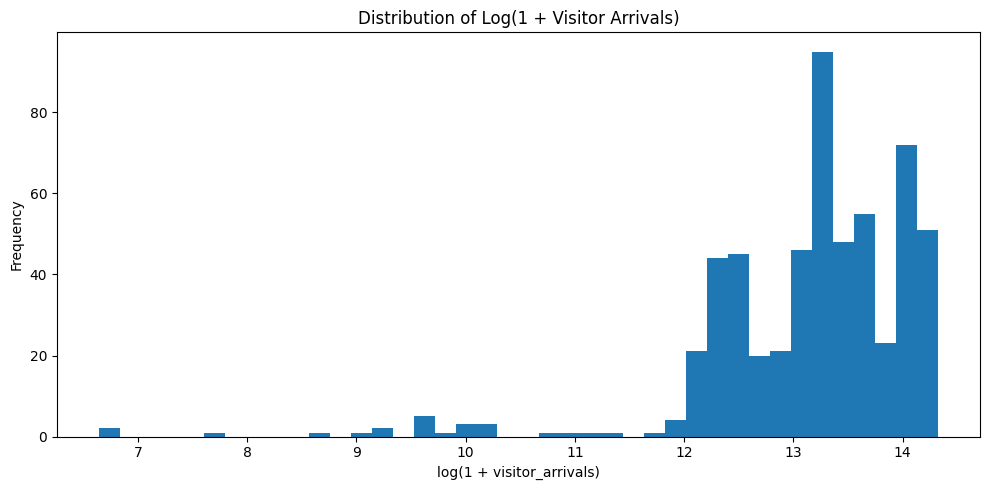

In [39]:
total_data["log_visitor_arrivals"] = np.log1p(total_data["total_visitor_arrivals"])

plt.figure(figsize=(10, 5))
plt.hist(total_data["log_visitor_arrivals"].dropna(), bins=40)
plt.title("Distribution of Log(1 + Visitor Arrivals)")
plt.xlabel("log(1 + visitor_arrivals)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [40]:
data["log_visitor_arrivals"] = np.log1p(data["visitor_arrivals"])

In [41]:
numeric_cols = filtered_data.select_dtypes(include=[np.number]).columns.tolist()

corr = filtered_data[numeric_cols].corr(numeric_only=True)
target_corr = corr["visitor_arrivals"].sort_values(ascending=False)

target_corr

visitor_arrivals        1.000000
aircraft_passengers     0.358851
traffic_volume          0.312924
hotel_occupancy         0.302147
hotel_rate              0.248802
gdp                     0.218258
public_holiday_count   -0.023864
exchange_rate          -0.329787
Name: visitor_arrivals, dtype: float64

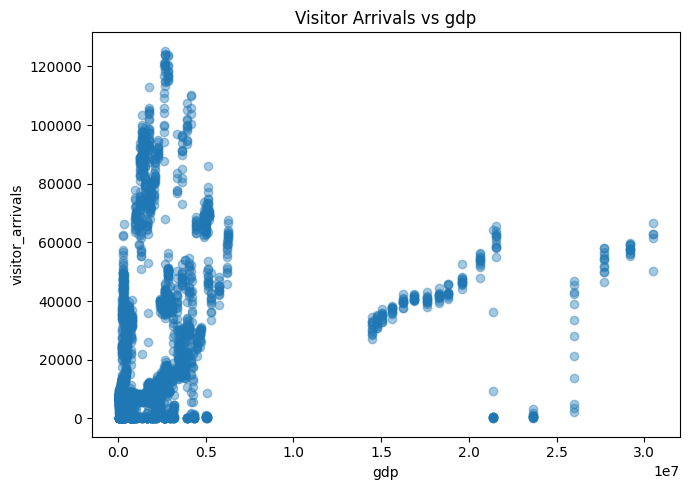

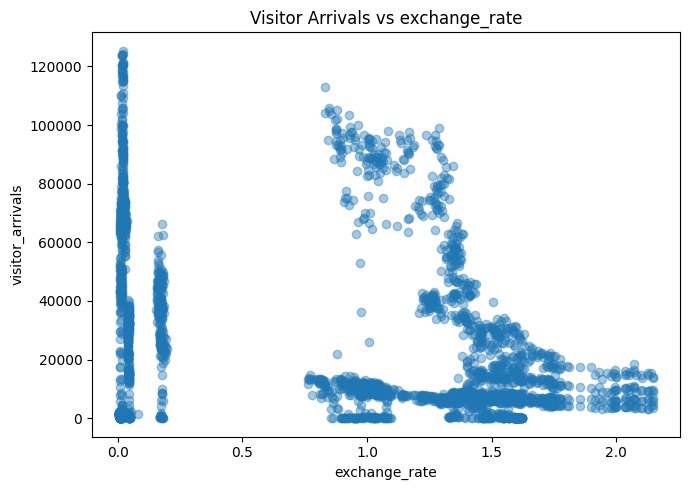

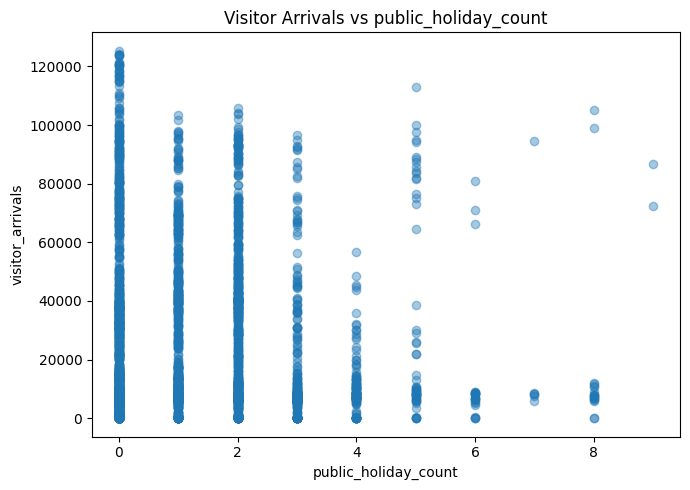

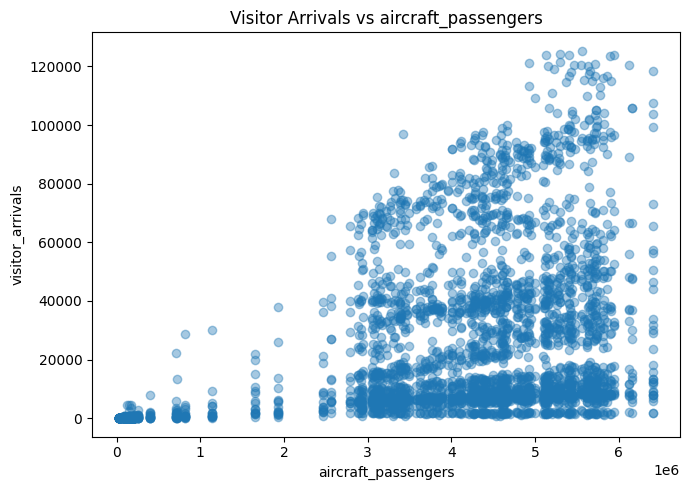

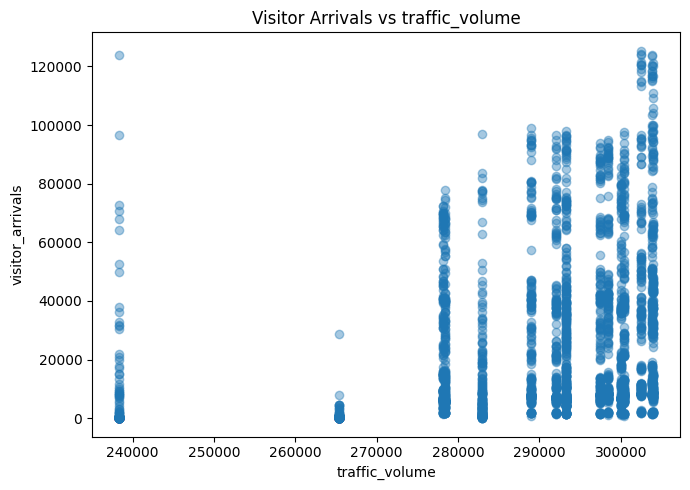

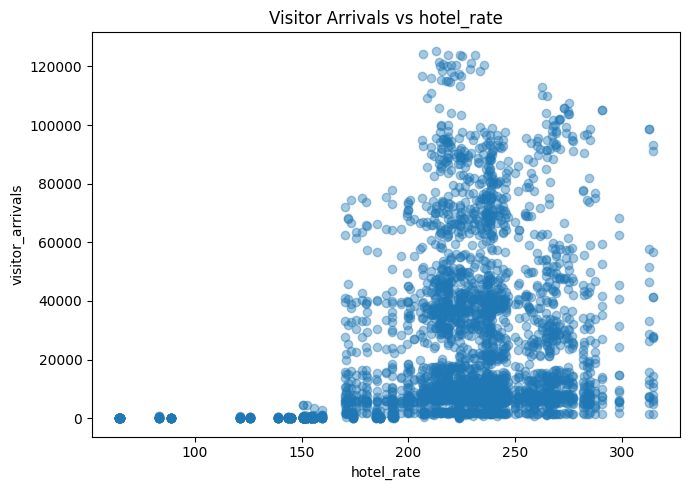

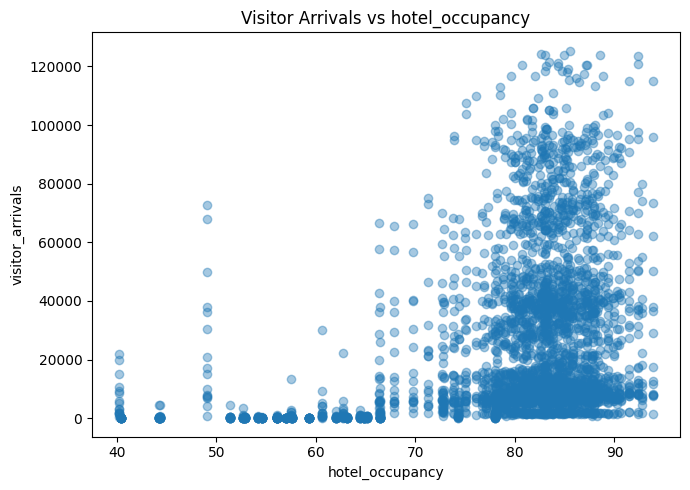

In [42]:
candidate_features = [
    "gdp",
    "exchange_rate",
    "public_holiday_count",
    "aircraft_passengers",
    "traffic_volume",
    "hotel_rate",
    "hotel_occupancy"
]

for col in candidate_features:
    if col in filtered_data.columns:
        temp = filtered_data[[col, "visitor_arrivals"]].dropna()
        if len(temp) > 0:
            plt.figure(figsize=(7, 5))
            plt.scatter(temp[col], temp["visitor_arrivals"], alpha=0.4)
            plt.title(f"Visitor Arrivals vs {col}")
            plt.xlabel(col)
            plt.ylabel("visitor_arrivals")
            plt.tight_layout()
            plt.show()

In [43]:
coverage = data.groupby("country")["month"].nunique().sort_values(ascending=False)
coverage.describe()

count     16.0
mean     569.0
std        0.0
min      569.0
25%      569.0
50%      569.0
75%      569.0
max      569.0
Name: month, dtype: float64

In [44]:
print("Quick observations:")
print(f"- Total rows: {len(data)}")
print(f"- Number of countries: {data['country'].nunique()}")
print(f"- Months covered: {data['month'].nunique()}")
print(f"- Date range: {data['month'].min().date()} to {data['month'].max().date()}")
print("\nTop null percentages:")
print(missing.head(10))

Quick observations:
- Total rows: 9104
- Number of countries: 16
- Months covered: 569
- Date range: 1978-01-01 to 2025-05-01

Top null percentages:
                      null_count  null_pct
hotel_rate                  5760     63.27
hotel_occupancy             5760     63.27
exchange_rate               5508     60.50
traffic_volume              5264     57.82
aircraft_passengers          384      4.22
gdp                           34      0.37
country                        0      0.00
month                          0      0.00
visitor_arrivals               0      0.00
public_holiday_count           0      0.00


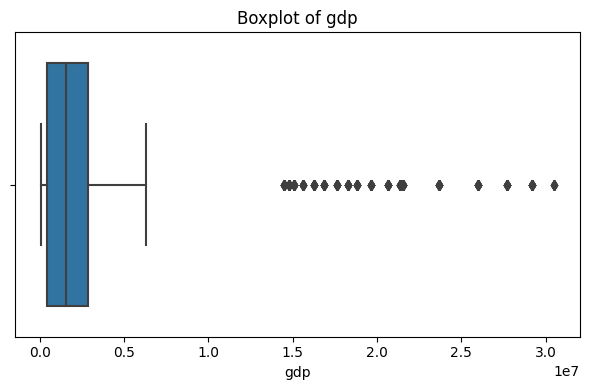

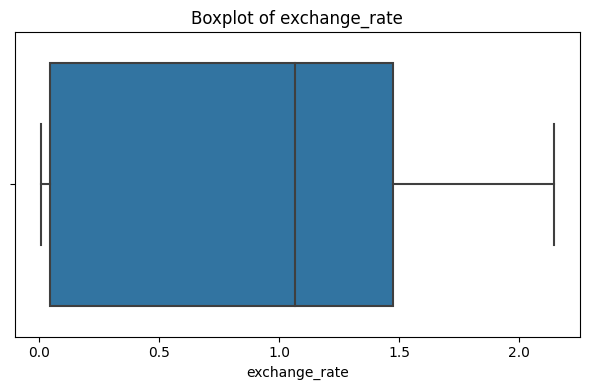

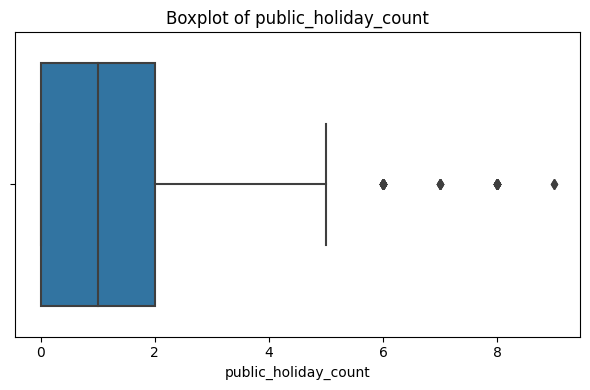

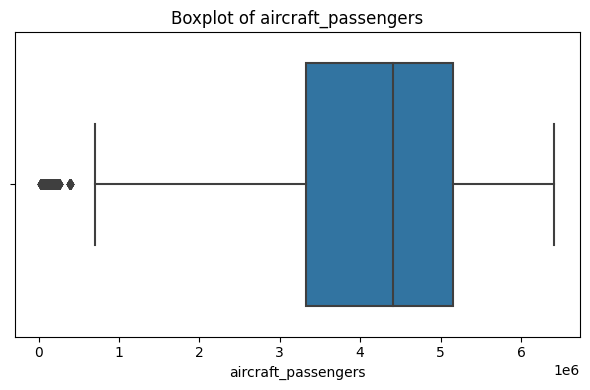

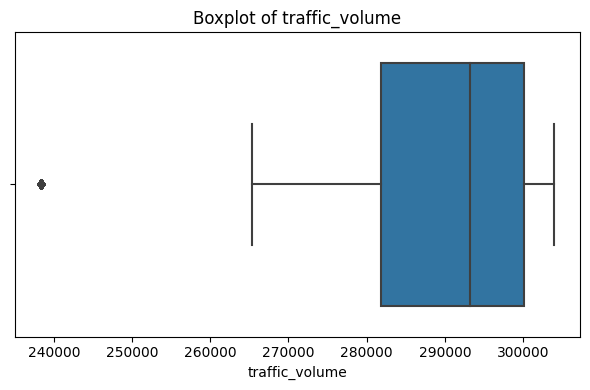

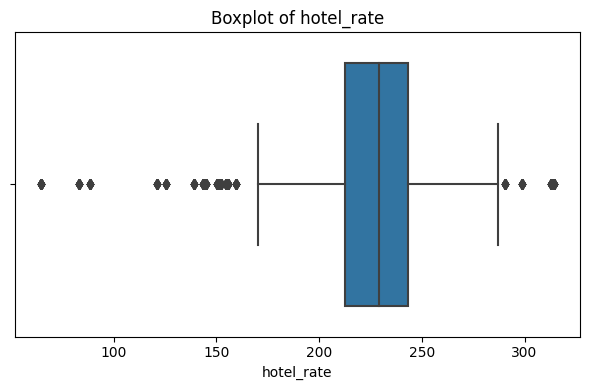

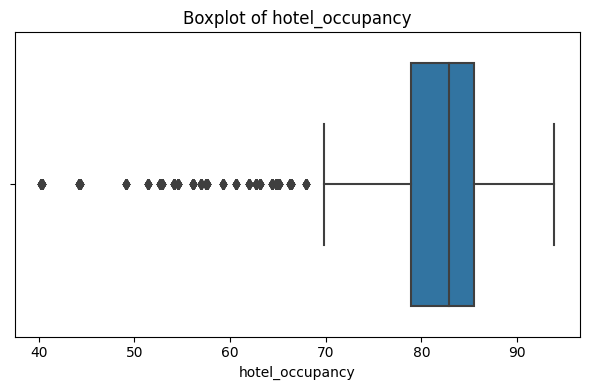

In [45]:
for col in candidate_features:
    if col in data.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=filtered_data[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.show()

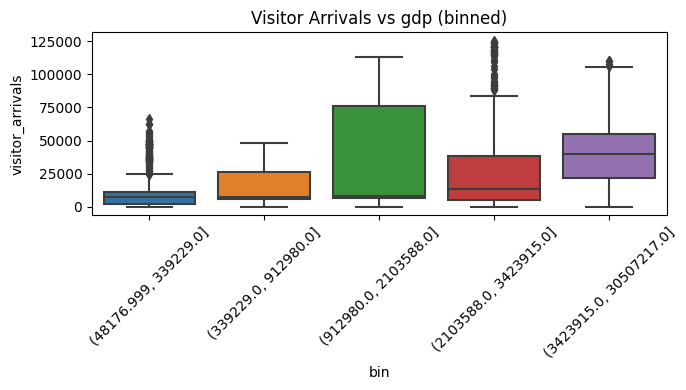

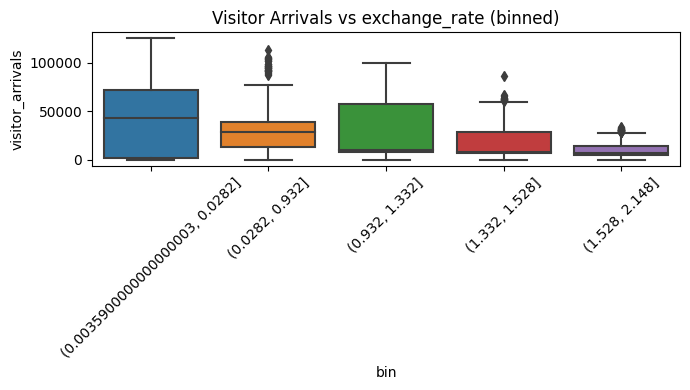

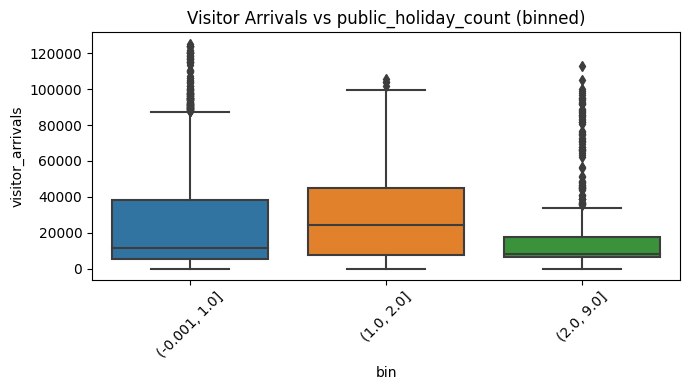

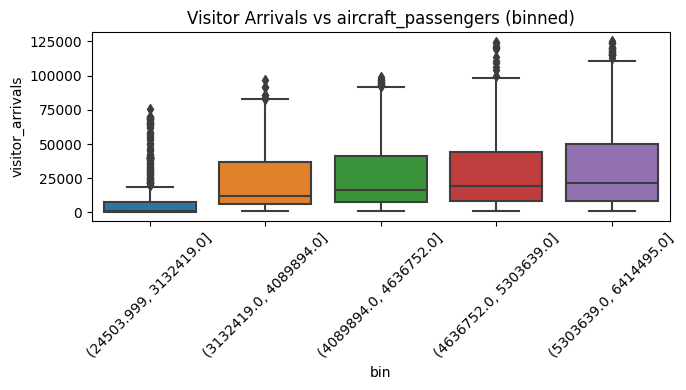

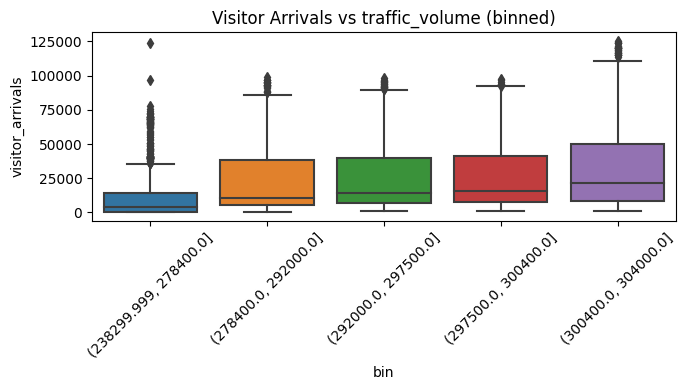

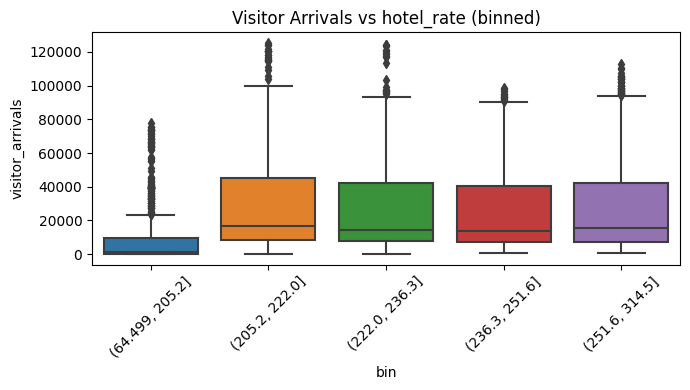

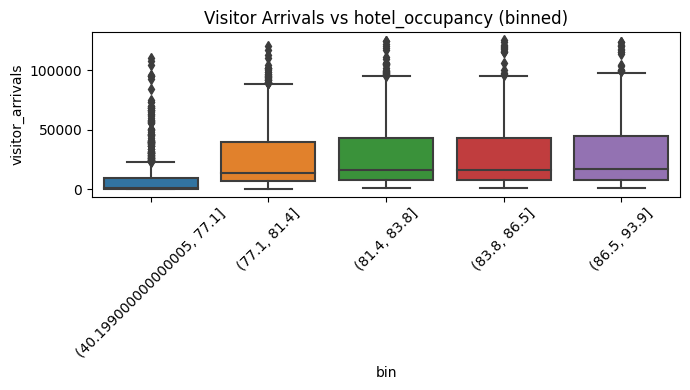

In [46]:
for col in candidate_features:
    if col in filtered_data.columns:
        temp = filtered_data[[col, "visitor_arrivals"]].dropna()
        
        # create bins
        temp["bin"] = pd.qcut(temp[col], q=5, duplicates="drop")
        
        plt.figure(figsize=(7, 4))
        sns.boxplot(x="bin", y="visitor_arrivals", data=temp)
        plt.title(f"Visitor Arrivals vs {col} (binned)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

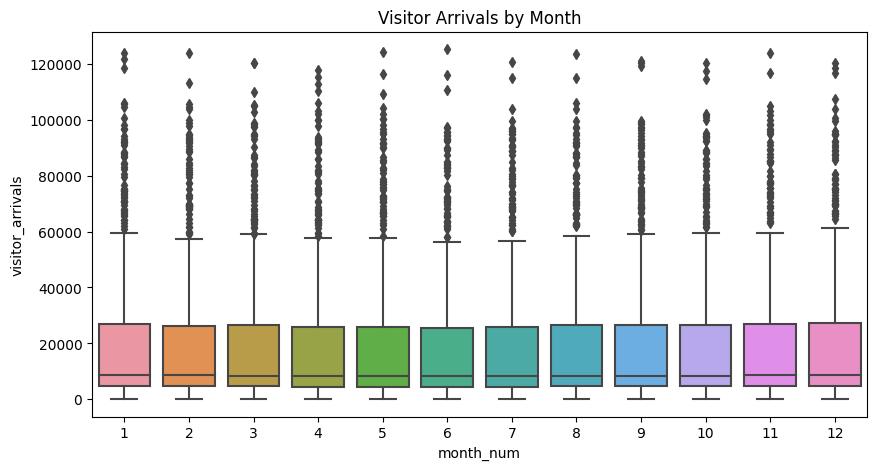

In [48]:
data["month_num"] = data["month"].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(x="month_num", y="visitor_arrivals", data=data)
plt.title("Visitor Arrivals by Month")
plt.show()